# 👤 Author
## Rezk Youssef Rezk


#Import libraries
This section is dedicated to importing all necessary Python libraries and modules required for the data analysis, model building, training, evaluation, and visualization steps in this notebook. Importing them at the beginning ensures that all functionalities are available throughout the subsequent processes.

In [ ]:
import pandas as pd  # Used for data manipulation and analysis.
from IPython.display import display # used to diplay dataframes into tables
import numpy as np  # Used for numerical operations, especially with arrays.
import tensorflow as tf  # Used for building and training neural networks.
from sklearn.model_selection import train_test_split  # Used for splitting data into training and testing sets.
from sklearn.preprocessing import StandardScaler  # Used for scaling numerical features.
from sklearn.metrics import accuracy_score, classification_report  # Used for evaluating model performance.
import matplotlib.pyplot as plt  # Used for creating visualizations.
import os  # Used for interacting with the operating system, like file paths.
import random #used for picking items at random from a collection.
from sklearn.metrics import confusion_matrix #used to show confusion matrix.
import seaborn as sns #used for Visualizing a Confusion Matrix.


#Data import and preprocessing

This section covers the initial steps of handling the dataset, from importing it into the environment to performing basic preprocessing. This ensures the data is in a suitable format for subsequent modeling tasks.


In [ ]:
#dataset
import kagglehub
path = kagglehub.dataset_download("ankitbatra1210/diabetes-dataset")

100%|██████████| 2.35M/2.35M [00:01<00:00, 2.22MB/s]

Extracting files...


In [ ]:
# 1. Load the dataset
# Retrieve a list of all files and folders within the specified directory
dataset_files = os.listdir(path)

# Identify the CSV file by filtering the list for files ending in '.csv'
# This assumes there is at least one CSV file and selects the first one found
csv_file = [f for f in dataset_files if f.endswith('.csv')][0]

# Construct the full absolute path to the CSV file for loading
data_path = os.path.join(path, csv_file)

# Read the CSV file into a pandas DataFrame object
df = pd.read_csv(data_path)

# Confirm the file location to the console
print(f"Dataset loaded from: {data_path}")

# Output the first 5 rows of the data to verify it loaded correctly
print("Dataset head:")
display(df.head()) # Use display() for a cleaner, rendered table view in notebooks

# Display structural information including column names, data types, and null counts
print("Dataset info:")
df.info()

Dataset loaded from: /root/.cache/kagglehub/datasets/ankitbatra1210/diabetes-dataset/versions/1/diabetes_dataset00.csv
Dataset head:


,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Target                         70000 non-null  object
 1   Genetic Markers                70000 non-null  object
 2   Autoantibodies                 70000 non-null  object
 3   Family History                 70000 non-null  object
 4   Environmental Factors          70000 non-null  object
 5   Insulin Levels                 70000 non-null  int64 
 6   Age                            70000 non-null  int64 
 7   BMI                            70000 non-null  int64 
 8   Physical Activity              70000 non-null  object
 9   Dietary Habits                 70000 non-null  object
 10  Blood Pressure                 70000 non-null  int64 
 11  Cholesterol Levels             70000 non-null  int64 
 12  Waist Circumference            70000 non-null 


# 2. Data Preprocessing and Normalization involves:
 This section performs crucial data preprocessing steps to prepare the dataset for model training.

    - Handling potential missing values (represented as 0s in specific numeric columns) by replacing them with the mean.
    - Creating a binary 'Outcome' target variable from the 'Target' column.
    - One-hot encoding categorical features to convert them into a numerical format suitable for the model.
    - Splitting the data into training and testing sets.
    - Scaling numerical features to ensure they contribute equally to the model's learning process.


In [ ]:

# --- 1. Define columns that might have 0s representing missing values in this dataset
# Based on df.info() and df.head(), these are the most likely candidates.
# In medical datasets, 0 is often a placeholder for missing data (e.g., a BMI of 0 is physically impossible).
relevant_numeric_cols_for_imputation = ['Blood Glucose Levels', 'Blood Pressure', 'Insulin Levels', 'BMI']

# Check for missing values (0s treated as missing for some columns)
print("\nMissing values (0s treated as missing for some columns):")
# Create a list of columns that exist in the current DataFrame to avoid KeyErrors
# Only check columns that actually exist in the dataframe
existing_cols_to_check = [col for col in relevant_numeric_cols_for_imputation if col in df.columns]
if existing_cols_to_check:
    # Count how many rows contain a 0 in these specific columns
    display(df[existing_cols_to_check].isin([0]).sum())
else:
    print("No relevant numeric columns found to check for 0s.")

# --- 2. Impute missing values ---
# Replace zeros with NaN (Not a Number) so they don't skew the mean calculation

for col in existing_cols_to_check:
    df[col] = df[col].replace(0, np.nan)
    # Fill those NaNs with the average value of that specific column
    df[col] = df[col].fillna(df[col].mean())

print("\nDataset head after imputing 0s:")
display(df.head(20))

# --- 3. Feature Engineering: Target Transformation ---
# Convert the descriptive 'Target' string column into a binary numeric 'Outcome' (1 for positive, 0 for negative)
# Assuming any 'Target' value containing 'Diabetes' implies diabetes (1), otherwise no diabetes (0)
df['Outcome'] = df['Target'].apply(lambda x: 1 if 'Diabetes' in x else 0)
print(f"\nDistribution of new 'Outcome' column:\n{df['Outcome'].value_counts()}")

# --- 4. Categorical Encoding ---
# Automatically find text/object columns that need to be converted to numbers for the model
# Identify categorical columns for one-hot encoding (excluding 'Target' as it's used for 'Outcome')
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'Target' from categorical_cols as it's already processed into 'Outcome'
if 'Target' in categorical_cols:
    categorical_cols.remove('Target')

print(f"\nCategorical columns to one-hot encode: {categorical_cols}")

# Apply one-hot encoding
# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

print("\nDataset head after one-hot encoding:")
display(df.head(20))
print("Dataset info after one-hot encoding:")
df.info()

# --- 5. Feature-Target Split ---
# Define X (features used for prediction) and y (the value we want to predict)
# Split features (X) and target (y)
# Drop the original 'Target' column as 'Outcome' is now the binary target
X = df.drop(['Outcome', 'Target'], axis=1)
y = df['Outcome']

# --- 6. Train-Test Split ---
# Split data: 80% for training the model, 20% for testing its accuracy
# stratify=y ensures the ratio of diabetic to non-diabetic cases is the same in both sets
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 7. Feature Scaling ---
# Standardize features (mean=0, variance=1) so that features with large ranges don't dominate the model
scaler = StandardScaler()
# Calculate scaling parameters on training data ONLY, then apply to both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nX_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")


Missing values (0s treated as missing for some columns):


,0
Blood Glucose Levels,0
Blood Pressure,0
Insulin Levels,0
BMI,0



Dataset head after imputing 0s:


,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No
5,LADA,Positive,Negative,Yes,Present,17,41,26,Moderate,Healthy,...,85,Yes,No,Negative,2,Normal,52,Ketones Present,3835,Yes
6,Type 2 Diabetes,Negative,Negative,No,Absent,29,30,31,Moderate,Healthy,...,64,Yes,Yes,Negative,3,Abnormal,96,Ketones Present,4426,No
7,Wolcott-Rallison Syndrome,Positive,Negative,No,Absent,10,3,18,Low,Unhealthy,...,44,Yes,No,Negative,1,Normal,29,Ketones Present,1644,Yes
8,Secondary Diabetes,Negative,Positive,No,Absent,47,47,25,High,Healthy,...,71,No,Yes,Positive,3,Normal,74,Ketones Present,3721,No
9,Secondary Diabetes,Positive,Negative,Yes,Present,21,72,24,Low,Unhealthy,...,69,Yes,Yes,Positive,2,Abnormal,42,Protein Present,4206,No



Distribution of new 'Outcome' column:
Outcome
1    43133
0    26867
Name: count, dtype: int64

Categorical columns to one-hot encode: ['Genetic Markers', 'Autoantibodies', 'Family History', 'Environmental Factors', 'Physical Activity', 'Dietary Habits', 'Ethnicity', 'Socioeconomic Factors', 'Smoking Status', 'Alcohol Consumption', 'Glucose Tolerance Test', 'History of PCOS', 'Previous Gestational Diabetes', 'Pregnancy History', 'Cystic Fibrosis Diagnosis', 'Steroid Use History', 'Genetic Testing', 'Liver Function Tests', 'Urine Test', 'Early Onset Symptoms']

Dataset head after one-hot encoding:


,Target,Insulin Levels,Age,BMI,Blood Pressure,Cholesterol Levels,Waist Circumference,Blood Glucose Levels,Weight Gain During Pregnancy,Pancreatic Health,...,Previous Gestational Diabetes_Yes,Pregnancy History_Normal,Cystic Fibrosis Diagnosis_Yes,Steroid Use History_Yes,Genetic Testing_Positive,Liver Function Tests_Normal,Urine Test_Ketones Present,Urine Test_Normal,Urine Test_Protein Present,Early Onset Symptoms_Yes
0,Steroid-Induced Diabetes,40,44,38,124,201,50,168,18,36,...,False,True,False,False,True,True,True,False,False,False
1,Neonatal Diabetes Mellitus (NDM),13,1,17,73,121,24,178,8,26,...,False,True,True,False,False,True,False,False,False,True
2,Prediabetic,27,36,24,121,185,36,105,15,56,...,False,True,True,False,False,False,True,False,False,True
3,Type 1 Diabetes,8,7,16,100,151,29,121,12,49,...,True,True,True,False,True,False,True,False,False,False
4,Wolfram Syndrome,17,10,17,103,146,33,289,2,10,...,True,False,False,False,True,True,False,False,True,False
5,LADA,17,41,26,127,208,32,142,11,40,...,False,True,True,False,False,True,True,False,False,True
6,Type 2 Diabetes,29,30,31,115,237,43,186,15,62,...,True,True,True,True,False,False,True,False,False,False
7,Wolcott-Rallison Syndrome,10,3,18,80,157,29,206,4,13,...,True,True,True,False,False,True,True,False,False,True
8,Secondary Diabetes,47,47,25,138,185,40,160,30,91,...,False,False,False,True,True,True,True,False,False,False
9,Secondary Diabetes,21,72,24,136,259,36,192,33,86,...,False,True,True,True,True,False,False,False,True,False


Dataset info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Target                             70000 non-null  object
 1   Insulin Levels                     70000 non-null  int64 
 2   Age                                70000 non-null  int64 
 3   BMI                                70000 non-null  int64 
 4   Blood Pressure                     70000 non-null  int64 
 5   Cholesterol Levels                 70000 non-null  int64 
 6   Waist Circumference                70000 non-null  int64 
 7   Blood Glucose Levels               70000 non-null  int64 
 8   Weight Gain During Pregnancy       70000 non-null  int64 
 9   Pancreatic Health                  70000 non-null  int64 
 10  Pulmonary Function                 70000 non-null  int64 
 11  Neurological Assessments      

#Modeling

The modeling section constructs a Feedforward Neural Network (FNN) using TensorFlow's Keras API for binary classification. This type of network is well-suited for tabular data and binary outcomes.

### Model Architecture:
-   **Input Layer**: Takes the scaled numerical features as input, with the shape matching the number of features in `X_train_scaled`.
-   **Hidden Layers**: Two `Dense` layers with `relu` activation functions are used to introduce non-linearity. The first hidden layer has 128 units, and the second has 64 units.
-   **Dropout Layers**: `Dropout` layers (with a rate of 0.3) are included after each hidden layer. These randomly set a fraction of input units to 0 at each update during training, which helps prevent overfitting by forcing the network to learn more robust features.
-   **Output Layer**: A single `Dense` unit with a `sigmoid` activation function is used for binary classification. The sigmoid function squashes the output between 0 and 1, which can be interpreted as the probability of the positive class (i.e., having diabetes).

### Model Compilation:
-   **Optimizer**: The `adam` optimizer is chosen for its efficiency and good performance in a wide range of tasks.
-   **Loss Function**: `binary_crossentropy` is the standard loss function for binary classification problems, measuring the error between predicted probabilities and actual binary labels.
-   **Metrics**: `accuracy` is used to monitor the model's performance during training and evaluation, representing the proportion of correctly classified instances.

In [ ]:
# 3. Build a Neural Network Model

# Explain model choice: A simple Feedforward Neural Network (FNN) with a few dense layers is suitable
# for this binary classification task with tabular data. The sigmoid activation in the output layer
# is used for binary classification, and ReLU for hidden layers is common for non-linearity.

# --- Model Architecture ---
# We are using a Sequential API, which stacks layers linearly.
# A Feedforward Neural Network (FNN) is ideal here because our data is tabular (rows and columns).
model = tf.keras.Sequential([
    # Input Layer: Must match the number of features in our scaled training data
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)), # Input layer
    # First Hidden Layer: 128 neurons.
    # 'relu' (Rectified Linear Unit) helps the model learn complex, non-linear patterns.
    tf.keras.layers.Dense(128, activation='relu', name='hidden_layer_1'), # First hidden layer
    # Dropout Layer: Randomly "shuts off" 30% of neurons during training.
    # This prevents the model from relying too heavily on specific neurons (prevents overfitting).
    tf.keras.layers.Dropout(0.3), # Dropout for regularization
    # Second Hidden Layer: A smaller layer (64 neurons) to further condense the learned features.
    tf.keras.layers.Dense(64, activation='relu', name='hidden_layer_2'),  # Second hidden layer
    # Output Layer: A single neuron with 'sigmoid' activation.
    # Sigmoid squashes the output value between 0 and 1, representing the probability of the positive class.
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid', name='output_layer')   # Output layer for binary classification
])

# --- Model Compilation ---
# This step configures the learning process before training starts.
model.compile(
    # 'adam' is an adaptive optimizer that adjusts the learning rate automatically
    optimizer='adam',
    # 'binary_crossentropy' is the standard loss function for 0-vs-1 classification
    loss='binary_crossentropy',
    # We track 'accuracy' to see what percentage of predictions the model gets right
    metrics=['accuracy'])

# Display the architecture, showing the number of trainable parameters (weights and biases)
print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

#Training

This section trains the previously defined neural network model using the prepared training data.

### Training Process:
-   **`model.fit()`**: This method is used to train the model.
-   **`X_train_scaled`, `y_train`**: The scaled training features and corresponding labels are passed to the model.
-   **`epochs=100`**: The model will iterate over the entire dataset 100 times. Each epoch allows the model to learn from the data and adjust its weights.
-   **`batch_size=32`**: The training data is divided into batches of 32 samples. The model's weights are updated after processing each batch, making the training process more efficient than updating after every single sample.
-   **`validation_split=0.2`**: 20% of the training data is held out to be used as a validation set. This helps monitor the model's performance on unseen data during training, providing insights into potential overfitting or underfitting.
-   **`verbose=1`**: This setting ensures that the training progress, including accuracy and loss for both training and validation sets, is displayed for each epoch. This allows us to observe how the model learns over time.

In [ ]:
# 4. Train the Model
print("\nModel training starting...")
# The .fit() method starts the training process and stores progress in the 'history' object
history = model.fit(X_train_scaled, y_train,
                    # Epochs: The number of times the model passes through the entire training dataset
                    epochs=100,
                    # Batch Size: The number of samples processed before the model updates its internal weights
                    # Smaller batches can lead to more stable learning but take longer
                    batch_size=32,
                    # Validation Split: Reserves 20% of the training data to monitor performance on unseen data
                    # after each epoch. This helps detect overfitting in real-time.
                    validation_split=0.2,
                    verbose=1) # Set verbose to 1 to see progress

print("\nModel training complete.")


Model training starting...
Epoch 1/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8438 - loss: 0.3083 - val_accuracy: 0.8948 - val_loss: 0.2167
Epoch 2/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8888 - loss: 0.2300 - val_accuracy: 0.9042 - val_loss: 0.1973
Epoch 3/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9037 - loss: 0.2049 - val_accuracy: 0.9168 - val_loss: 0.1784
Epoch 4/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9127 - loss: 0.1883 - val_accuracy: 0.9243 - val_loss: 0.1648
Epoch 5/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9193 - loss: 0.1753 - val_accuracy: 0.9283 - val_loss: 0.1575
Epoch 6/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9211 - loss: 0.1697 - val_accuracy: 0.9273 - val_loss: 0.1563
Epoch 7/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9249 - loss: 0.1636 - val_accuracy: 0.9308 - val_loss: 0.1531
Epoch 8/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

#Testing

This section evaluates the trained neural network model on the unseen test data (`X_test_scaled`, `y_test`) to assess its generalization performance.

### Evaluation Steps:
-   **Model Evaluation**: The `model.evaluate()` method calculates the loss and accuracy of the model on the test set. This provides a direct measure of how well the model performs on new, unseen data.
-   **Prediction Generation**: `model.predict()` is used to generate probability predictions (`y_pred_proba`) for the test set. These probabilities are then converted into binary class predictions (`y_pred`) using a threshold of 0.5.
-   **Classification Report**: `sklearn.metrics.classification_report` generates a detailed report that includes precision, recall, f1-score, and support for each class (0 and 1). This report provides a comprehensive view of the model's performance beyond just overall accuracy, especially useful for imbalanced datasets.

This evaluation helps understand the model's strengths and weaknesses in distinguishing between the two classes (diabetes vs. non-diabetes).

In [ ]:
# 5. Evaluate the Model

# Calculate the model's performance on the 20% of data it has never seen before
# model.evaluate returns the loss value and any metrics requested (accuracy)
print("\nModel evaluation starting...")
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate raw prediction probabilities for the test set
# These values will range from 0.0 to 1.0 due to the sigmoid activation in the output layer
print("\nGenerating prediction probabilities...")
y_pred_proba = model.predict(X_test_scaled)
# Convert probabilities into binary classes (0 or 1)
# Using 0.5 as the decision threshold:
# If prob > 0.5, classify as 1 (Diabetic); otherwise 0 (Non-Diabetic)
y_pred = (y_pred_proba > 0.5).astype(int)

# The classification report provides a detailed breakdown of performance
# Precision: How many of the predicted positives were actually positive?
# Recall: How many of the actual positives did the model catch?
# F1-Score: The harmonic mean of precision and recall
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model evaluation starting...
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9398 - loss: 0.1365

Test Loss: 0.1365
Test Accuracy: 0.9398

Generating prediction probabilities...
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      5373
           1       0.94      0.96      0.95      8627

    accuracy                           0.94     14000
   macro avg       0.94      0.93      0.94     14000
weighted avg       0.94      0.94      0.94     14000



In [ ]:
# --- 1. Identify Correct vs. Incorrect Predictions ---
# np.where returns a tuple of indices where the condition is true
# We flatten y_pred to ensure the dimensions match y_test exactly
correct_indices = np.where(y_test == y_pred.flatten())[0]
incorrect_indices = np.where(y_test != y_pred.flatten())[0]

# --- 2. Random Sampling for Inspection ---
# We define how many examples we want to look at
num_samples = 5
# Use random.sample to pick unique indices from our lists
# min() ensures we don't try to pick more samples than actually exist
sample_correct_indices = random.sample(list(correct_indices), min(len(correct_indices), num_samples))
sample_incorrect_indices = random.sample(list(incorrect_indices), min(len(incorrect_indices), num_samples))

# --- 3. Display Correct Predictions ---
print(f"\nSample of {len(sample_correct_indices)} Correct Predictions:")
for i, idx in enumerate(sample_correct_indices):
    # .iloc[idx] gets the original label from the test set
    # .flatten()[idx] ensures we get the specific scalar value for that prediction
    print(f"Sample {i+1}: True: {y_test.iloc[idx]}, Predicted: {y_pred[idx][0]}, Prob: {y_pred_proba[idx][0]:.4f}")

# --- 4. Display Incorrect Predictions ---
print(f"\nSample of {len(sample_incorrect_indices)} Incorrect Predictions:")
for i, idx in enumerate(sample_incorrect_indices):
    # Pay close attention to the 'Prob' (Probability).
    # If it's near 0.5, the model was uncertain; if it's near 0 or 1, the model was confidently wrong.
    print(f"Sample {i+1}: True: {y_test.iloc[idx]}, Predicted: {y_pred[idx][0]}, Prob: {y_pred_proba[idx][0]:.4f}")


Sample of 5 Correct Predictions:
Sample 1: True: 1, Predicted: 1, Prob: 0.9845
Sample 2: True: 0, Predicted: 0, Prob: 0.0000
Sample 3: True: 1, Predicted: 1, Prob: 0.5182
Sample 4: True: 0, Predicted: 0, Prob: 0.0000
Sample 5: True: 1, Predicted: 1, Prob: 1.0000

Sample of 5 Incorrect Predictions:
Sample 1: True: 1, Predicted: 0, Prob: 0.1250
Sample 2: True: 0, Predicted: 1, Prob: 0.6110
Sample 3: True: 1, Predicted: 0, Prob: 0.2315
Sample 4: True: 1, Predicted: 0, Prob: 0.3839
Sample 5: True: 1, Predicted: 0, Prob: 0.0961


#Data Visulization

This section is dedicated to visualizing the training process and the model's performance. It includes plots for:

-   **Training & Validation Accuracy**: Shows how the model's accuracy on both the training and validation datasets changes over epochs, helping to identify overfitting or underfitting.
-   **Training & Validation Loss**: Illustrates the model's error rate on both datasets over epochs, providing further insights into its learning progress.
-   **Confusion Matrix**: A crucial tool for evaluating the performance of a classification model, displaying the number of true positives, true negatives, false positives, and false negatives.

In [ ]:
# 6. Plot Training Results
# Create a figure with a wider width (12 units) to accommodate two subplots side-by-side
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

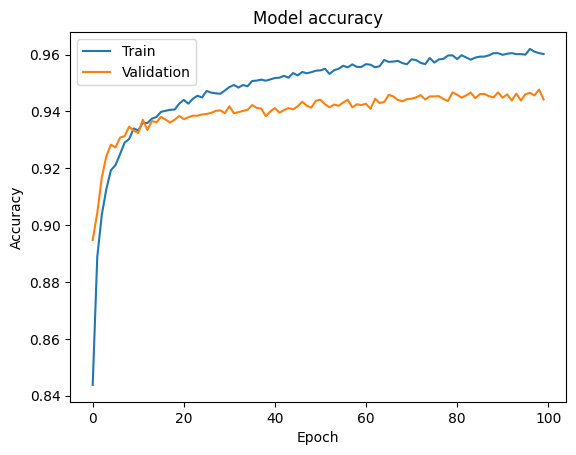

In [ ]:
# --- 1. Plot Training & Validation Accuracy ---
# Plot the accuracy recorded during training (on data the model saw)
plt.plot(history.history['accuracy'])
# Plot the accuracy recorded during validation (on data the model didn't use for weight updates)
plt.plot(history.history['val_accuracy'])
# Add clear labels so the graph is readable
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
# 'loc' defines where the legend box sits; 'upper left' keeps it away from the typical rising line
plt.legend(['Train', 'Validation'], loc='upper left')
# Display the plot
plt.show()

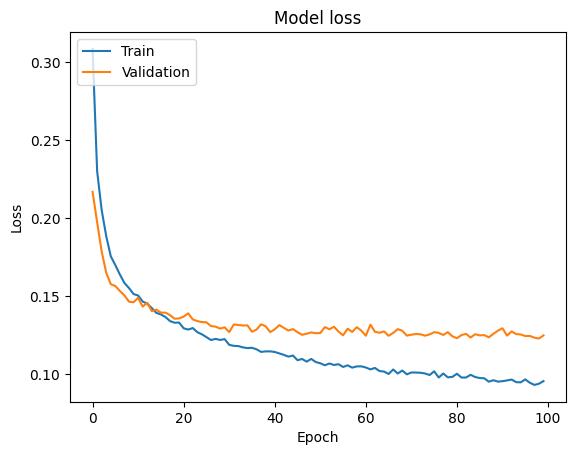

In [ ]:
# --- 1. Plot Training & Validation Loss ---
# Plot the 'loss' (error) on the training data
plt.plot(history.history['loss'])

# Plot the 'loss' on the validation data (the model's "exam")
plt.plot(history.history['val_loss'])

# Set the title and axis labels
plt.title('Model loss')
plt.ylabel('Loss')
# X-axis represents the training progress over time
plt.xlabel('Epoch')

# A legend is crucial to tell which line is which
plt.legend(['Train', 'Validation'], loc='upper left')

# Render the final plot
plt.show()

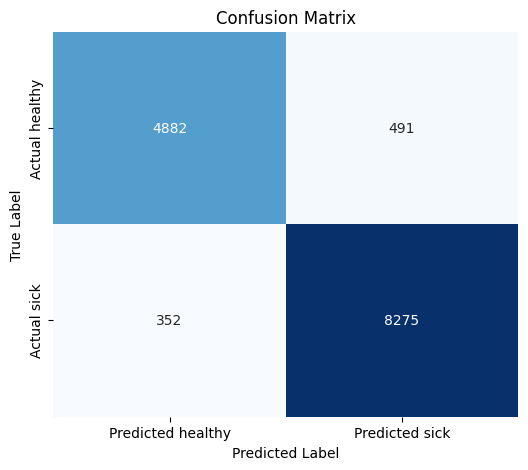

In [ ]:
# --- 1. Calculate the Confusion Matrix ---
# This creates a 2x2 grid (for binary classification) comparing actual vs. predicted labels
# Row 0: Actual Healthy, Row 1: Actual Sick
# Col 0: Predicted Healthy, Col 1: Predicted Sick
cm = confusion_matrix(y_test, y_pred)

# --- 2. Plotting the Heatmap ---
plt.figure(figsize=(6, 5))

# sns.heatmap creates a color-coded grid for easier reading
# annot=True: Writes the actual numbers in each cell
# fmt='d': Formats numbers as integers (decimals aren't needed here)
# cmap='Blues': Uses a blue color scale (darker = higher count)
# cbar=False: Removes the color scale bar for a cleaner look
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted healthy', 'Predicted sick'],
            yticklabels=['Actual healthy', 'Actual sick'])

# --- 3. Labeling the Plot ---
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Final command to render the plot
plt.show()

The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions. Let's also visualize a few examples to see where the model made correct and incorrect predictions.